# XGBoost with VGG16 for Image Classification
## Step 1 — Imports

In [1]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

2026-05-07 14:27:34.208918: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 14:27:34.210167: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 14:27:34.227307: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-07 14:27:34.227328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-07 14:27:34.227865: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## Step 2 — Configuration

In [3]:
IMG_SIZE = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)   # (224, 224, 3)

BASE_PATH = '/home/vineet/Downloads/XGBoost/chest-xray'

TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR   = os.path.join(BASE_PATH, 'val')
TEST_DIR  = os.path.join(BASE_PATH, 'test')

## Step 3 — Load Data

In [4]:
def load_images(split_dir):
    images = []
    labels = []

    for directory_path in glob.glob(os.path.join(split_dir, '*')):
        label = os.path.basename(directory_path)

        for img_path in glob.glob(os.path.join(directory_path, '*')):
            if os.path.basename(img_path).startswith('.'):
                continue

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [5]:
train_images, train_labels = load_images(TRAIN_DIR)
val_images,   val_labels   = load_images(VAL_DIR)
test_images,  test_labels  = load_images(TEST_DIR)

print("Train shape     :", train_images.shape)
print("Validation shape:", val_images.shape)
print("Test shape      :", test_images.shape)

Train shape     : (5216, 224, 224, 3)
Validation shape: (16, 224, 224, 3)
Test shape      : (624, 224, 224, 3)


## Step 4 — Label Encoding

In [6]:
le = preprocessing.LabelEncoder()

# Fit on all unique labels across every split to ensure consistent encoding
all_labels = np.concatenate([train_labels, val_labels, test_labels])
le.fit(all_labels)

train_labels_encoded = le.transform(train_labels)
val_labels_encoded   = le.transform(val_labels)
test_labels_encoded  = le.transform(test_labels)

CLASSES = list(le.classes_)

print("Classes:", CLASSES)
print("Train encoded labels :", np.unique(train_labels_encoded))
print("Val encoded labels   :", np.unique(val_labels_encoded))
print("Test encoded labels  :", np.unique(test_labels_encoded))

Classes: ['NORMAL', 'PNEUMONIA']
Train encoded labels : [0 1]
Val encoded labels   : [0 1]
Test encoded labels  : [0 1]


## Step 5 — Data Summary

In [7]:
def get_counts(split_dir):
    counts = {}
    for c in os.listdir(split_dir):
        class_path = os.path.join(split_dir, c)
        if not os.path.isdir(class_path):
            continue
        files = [f for f in os.listdir(class_path) if not f.startswith('.')]
        counts[c] = len(files)
    return counts

train_counts = get_counts(TRAIN_DIR)
val_counts   = get_counts(VAL_DIR)
test_counts  = get_counts(TEST_DIR)

all_categories = sorted(set(train_counts) | set(val_counts) | set(test_counts))

data_count = pd.DataFrame({
    'categories': all_categories,
    'train'     : [train_counts.get(c, 0) for c in all_categories],
    'val'       : [val_counts.get(c, 0)   for c in all_categories],
    'test'      : [test_counts.get(c, 0)  for c in all_categories]
})

data_count.to_csv(os.path.join(BASE_PATH, 'data_count.csv'), index=False)

data_count

,categories,train,val,test
0,NORMAL,1341,8,234
1,PNEUMONIA,3875,8,390


## Step 6 — VGG16 Setup

In [8]:
base_model = tf.keras.applications.VGG16(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

2026-05-07 14:27:48.940892: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-07 14:27:48.943196: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Step 7 — Feature Extraction

In [9]:
# preprocess_input applies VGG16-specific mean subtraction (BGR channel order from cv2)
train_features = base_model.predict(preprocess_input(train_images.astype('float32')))
train_features = train_features.reshape(train_features.shape[0], -1)
del train_images

val_features = base_model.predict(preprocess_input(val_images.astype('float32')))
val_features = val_features.reshape(val_features.shape[0], -1)
del val_images

test_features = base_model.predict(preprocess_input(test_images.astype('float32')))
test_features = test_features.reshape(test_features.shape[0], -1)
del test_images

print("Train features shape:", train_features.shape)
print("Val features shape  :", val_features.shape)
print("Test features shape :", test_features.shape)

20/20 [==============================] - 14s 716ms/step
Train features shape: (5216, 25088)
Val features shape  : (16, 25088)
Test features shape : (624, 25088)


## Step 8 — Data Sanity Check

In [10]:
print("Train labels :", set(train_labels_encoded))
print("Val labels   :", set(val_labels_encoded))
print("Test labels  :", set(test_labels_encoded))

print("\nNaN in train features:", np.isnan(train_features).sum())
print("NaN in val features  :", np.isnan(val_features).sum())
print("NaN in test features :", np.isnan(test_features).sum())

Train labels : {0, 1}
Val labels   : {0, 1}
Test labels  : {0, 1}

NaN in train features: 0
NaN in val features  : 0
NaN in test features : 0


## Step 9 — Train Initial Model

In [11]:
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    random_state=42
)

model.fit(
    train_features,
    train_labels_encoded,
    eval_set=[
        (train_features, train_labels_encoded),
        (val_features,   val_labels_encoded)
    ],
    verbose=True
)

# Store loss curves before model is replaced
init_results = model.evals_result()
init_train_loss = init_results['validation_0']['logloss']
init_val_loss   = init_results['validation_1']['logloss']

[0]	validation_0-logloss:0.51005	validation_1-logloss:0.72525
[1]	validation_0-logloss:0.46021	validation_1-logloss:0.67663
[2]	validation_0-logloss:0.41970	validation_1-logloss:0.62842
[3]	validation_0-logloss:0.38721	validation_1-logloss:0.58701
[4]	validation_0-logloss:0.35716	validation_1-logloss:0.57101
[5]	validation_0-logloss:0.33146	validation_1-logloss:0.54381
[6]	validation_0-logloss:0.30872	validation_1-logloss:0.52905
[7]	validation_0-logloss:0.28867	validation_1-logloss:0.53321
[8]	validation_0-logloss:0.27079	validation_1-logloss:0.52147
[9]	validation_0-logloss:0.25433	validation_1-logloss:0.49902
[10]	validation_0-logloss:0.23872	validation_1-logloss:0.49042
[11]	validation_0-logloss:0.22548	validation_1-logloss:0.48365
[12]	validation_0-logloss:0.21321	validation_1-logloss:0.46815
[13]	validation_0-logloss:0.20194	validation_1-logloss:0.44328
[14]	validation_0-logloss:0.19150	validation_1-logloss:0.43187
[15]	validation_0-logloss:0.18168	validation_1-logloss:0.41382
[1

## Step 10 — Find Best Iteration & Retrain Final Model

In [12]:
best_iteration  = int(np.argmin(init_val_loss))
best_ntree_limit = best_iteration + 1   # argmin is 0-indexed

print(f"Best iteration      : {best_iteration}")
print(f"Best n_estimators   : {best_ntree_limit}")
print(f"Best validation loss: {init_val_loss[best_iteration]:.6f}")

model_final = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.1,
    n_estimators=best_ntree_limit,
    max_depth=3,
    random_state=42
)

model_final.fit(
    train_features,
    train_labels_encoded,
    eval_set=[
        (train_features, train_labels_encoded),
        (val_features,   val_labels_encoded)
    ],
    verbose=False
)

print("\n✓ Final model retrained with best parameters!")

Best iteration      : 99
Best n_estimators   : 100
Best validation loss: 0.158092

✓ Final model retrained with best parameters!


## Step 11 — Evaluate Final Model

In [13]:
train_predictions = model_final.predict(train_features)
val_predictions   = model_final.predict(val_features)
test_predictions  = model_final.predict(test_features)

def print_metrics(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    return acc, prec, rec, f1

tr_m  = print_metrics(train_labels_encoded, train_predictions, 'Train')
val_m = print_metrics(val_labels_encoded,   val_predictions,   'Val')
te_m  = print_metrics(test_labels_encoded,  test_predictions,  'Test')

print(f"{'Metric':<20} {'Train':<15} {'Validation':<15} {'Test':<15}")
print("-" * 65)
for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1 Score']):
    print(f"{metric:<20} {tr_m[i]:<15.4f} {val_m[i]:<15.4f} {te_m[i]:<15.4f}")
print("-" * 65)

Metric               Train           Validation      Test           
-----------------------------------------------------------------
Accuracy             1.0000          0.9375          0.7644         
Precision            1.0000          0.9444          0.8217         
Recall               1.0000          0.9375          0.7644         
F1 Score             1.0000          0.9373          0.7308         
-----------------------------------------------------------------


## Step 12 — Accuracy vs Training Data Percentage

In [14]:
percentages = [0.2, 0.4, 0.6, 0.8]
vgg_xgb_acc = []

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        train_features,
        train_labels_encoded,
        train_size=p,
        stratify=train_labels_encoded,
        random_state=42
    )

    m = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )
    m.fit(X_subset, y_subset)

    acc = accuracy_score(test_labels_encoded, m.predict(test_features))
    vgg_xgb_acc.append(acc * 100)

    print(f"{int(p * 100)}% training data  →  Accuracy = {acc * 100:.2f}%")

print("\nAccuracy list:", vgg_xgb_acc)

20% training data  →  Accuracy = 74.04%
40% training data  →  Accuracy = 76.92%
60% training data  →  Accuracy = 76.76%
80% training data  →  Accuracy = 77.88%

Accuracy list: [74.03846153846155, 76.92307692307693, 76.76282051282051, 77.88461538461539]


## Step 13 — Visualisation: Sample Images per Class

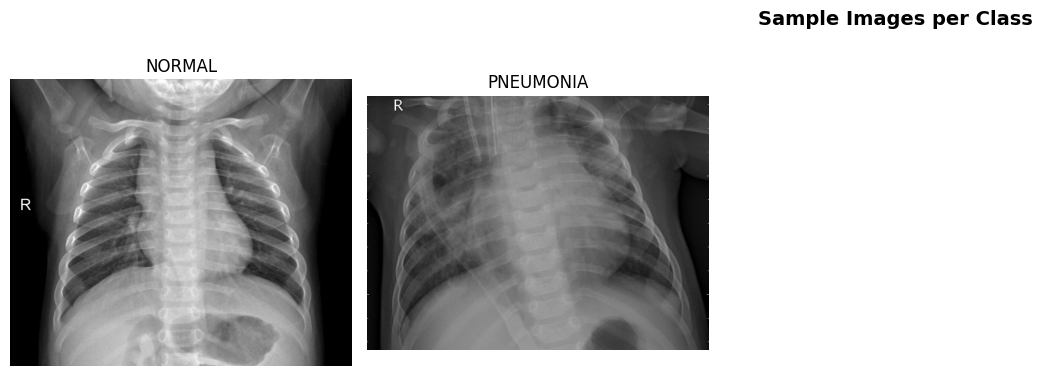

In [15]:
classes = [c for c in os.listdir(TRAIN_DIR)
           if os.path.isdir(os.path.join(TRAIN_DIR, c))]

plt.figure(figsize=(18, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    pic        = os.listdir(class_path)[0]
    image      = np.asarray(Image.open(os.path.join(class_path, pic)))

    plt.subplot(2, 5, i + 1)
    plt.title(class_name)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14 — Visualisation: Dataset Distribution

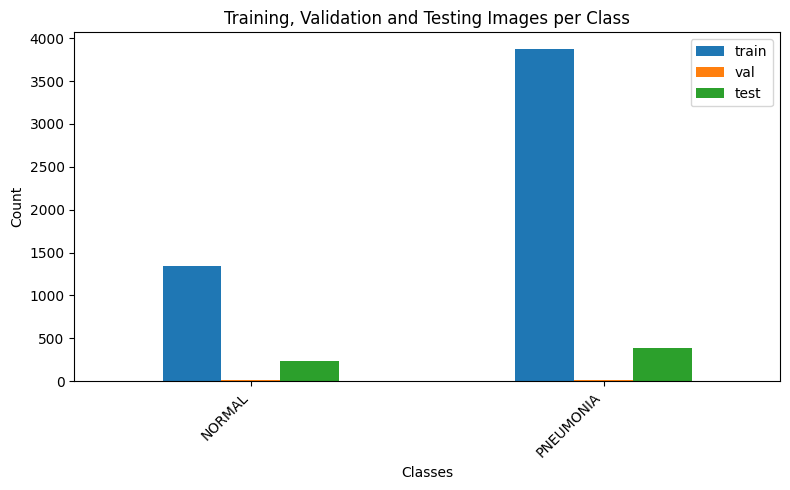

In [16]:
data_count.set_index('categories').plot(kind='bar', figsize=(8, 5))
plt.title('Training, Validation and Testing Images per Class')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 15 — Visualisation: Initial Model Learning Curves

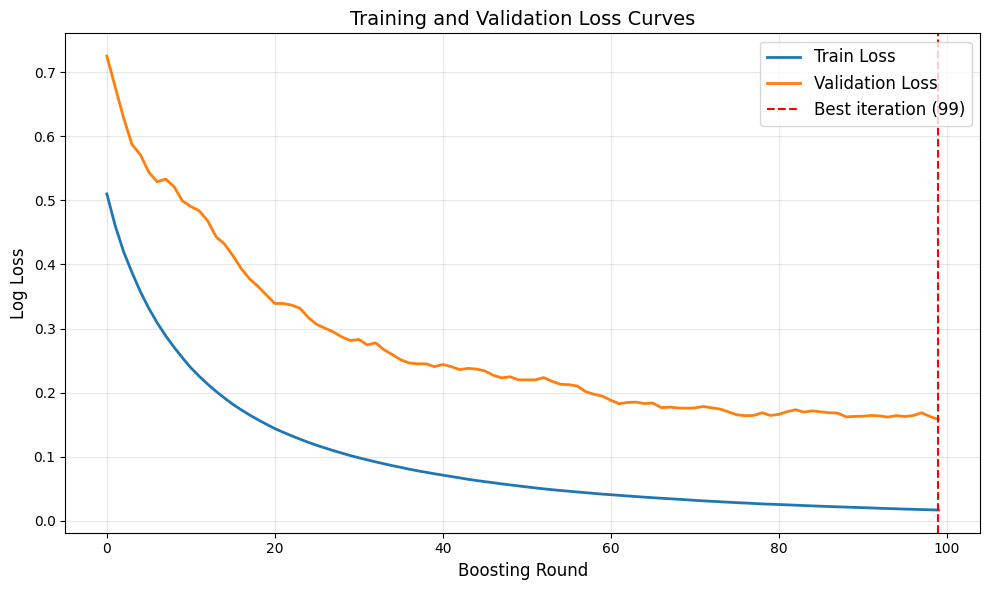

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(init_train_loss, label='Train Loss',      linewidth=2)
plt.plot(init_val_loss,   label='Validation Loss', linewidth=2)
plt.axvline(x=best_iteration, color='red', linestyle='--',
            linewidth=1.5, label=f'Best iteration ({best_iteration})')
plt.legend(loc='upper right', fontsize=12)
plt.xlabel('Boosting Round', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 16 — Visualisation: Confusion Matrix

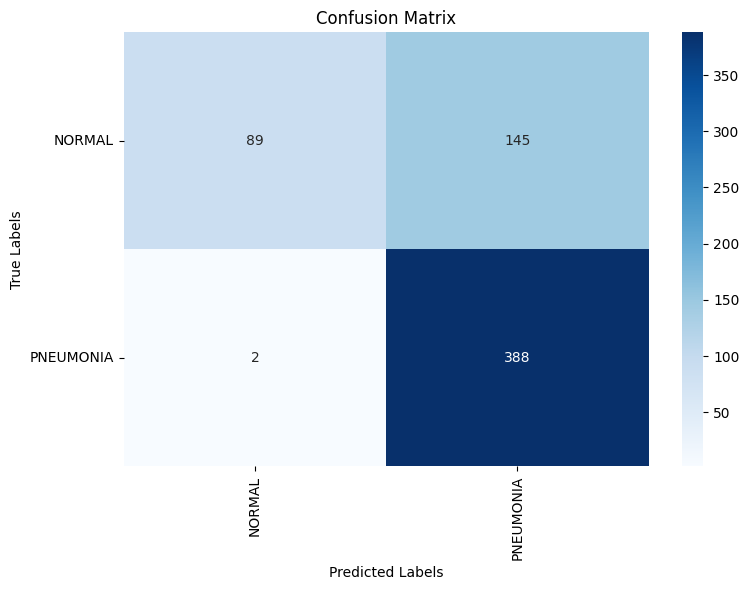

In [18]:
cf = confusion_matrix(test_labels_encoded, test_predictions)

plt.figure(figsize=(8, 6))
ax = plt.subplot()
sns.heatmap(cf, annot=True, fmt='g', cmap='Blues', ax=ax)

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.xaxis.set_ticklabels(CLASSES)
ax.yaxis.set_ticklabels(CLASSES)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 17 — Visualisation: Train vs Validation Loss per Data Percentage

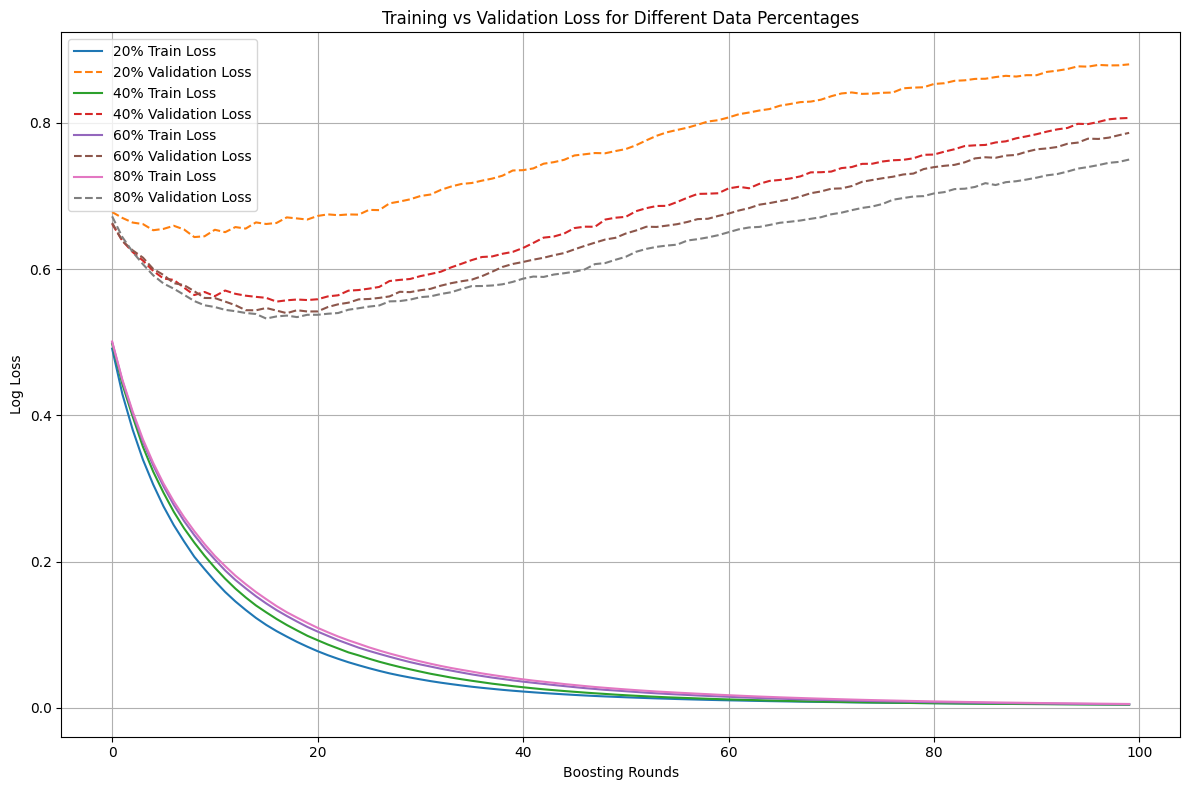

In [19]:
plt.figure(figsize=(12, 8))

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        train_features,
        train_labels_encoded,
        train_size=p,
        stratify=train_labels_encoded,
        random_state=42
    )

    m = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )

    eval_set = [
        (X_subset,     y_subset),
        (test_features, test_labels_encoded)
    ]

    m.fit(X_subset, y_subset, eval_set=eval_set, verbose=False)

    results    = m.evals_result()
    train_loss = results['validation_0']['logloss']
    val_loss   = results['validation_1']['logloss']

    plt.plot(train_loss,               label=f'{int(p * 100)}% Train Loss')
    plt.plot(val_loss, linestyle='--', label=f'{int(p * 100)}% Validation Loss')

plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different Data Percentages')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()